In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib nltk

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

In [4]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
df = pd.read_csv('/content/drive/MyDrive/chatgpt_style_reviews_dataset.xlsx - Sheet1.csv')
df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


In [ ]:
df.shape

(500, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   DATE               500 non-null    datetime64[ns]
 1   TITLE              500 non-null    object        
 2   REVIEW             500 non-null    object        
 3   RATING             500 non-null    int64         
 4   USERNAME           500 non-null    object        
 5   HELPFUL_VOTES      500 non-null    int64         
 6   REVIEW_LENGTH      500 non-null    int64         
 7   PLATFORM           500 non-null    object        
 8   LANGUAGE           500 non-null    object        
 9   LOCATION           500 non-null    object        
 10  VERSION            500 non-null    object        
 11  VERIFIED_PURCHASE  500 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(8)
memory usage: 47.0+ KB


In [ ]:
df.isnull().sum()

,0
date,0
title,0
review,0
rating,0
username,0
helpful_votes,0
review_length,0
platform,0
language,0
location,0


In [6]:
df.columns = df.columns.str.strip().str.upper().str.replace(" ", "_")

In [7]:
df['DATE'] = pd.to_datetime(
    df['DATE'],
    format='%m/%d/%Y',
    errors='coerce'
)

df['DATE'] = df['DATE'].bfill()

In [ ]:
df['DATE'].head(25)

,DATE
0,2024-05-05
1,2024-05-05
2,2024-05-05
3,2024-05-05
4,2024-05-05
5,2024-05-05
6,2024-03-09
7,2024-03-08
8,2024-06-02
9,2024-06-02


In [8]:
df['TITLE'] = df['TITLE'].str.lower().str.strip()

In [9]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [10]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

df["CLEAN_REVIEW"] = df["REVIEW"].apply(clean_text)

In [17]:
df

,DATE,TITLE,REVIEW,RATING,USERNAME,HELPFUL_VOTES,REVIEW_LENGTH,PLATFORM,LANGUAGE,LOCATION,VERSION,VERIFIED_PURCHASE,CLEAN_REVIEW
0,2024-05-05,review title 1,satisfied many bug issue,1,user1,80,6,Amazon,zh,Kenya,2.1.4,No,satisfied many bug issue
1,2024-05-05,review title 2,amazing quality userfriendly interface,5,user2,180,5,Flipkart,zh,France,1.2.3,No,amazing quality userfriendly interface
2,2024-05-05,review title 3,terrible experience need major improvement,2,user3,154,5,Flipkart,pt,USA,1.2.3,No,terrible experience need major improvement
3,2024-05-05,review title 4,poor performance userfriendly,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes,poor performance userfriendly
4,2024-05-05,review title 5,satisfied many bug issue,2,user5,139,6,Website,ar,Kenya,2.1.4,No,satisfied many bug issue
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2024-07-05,review title 496,waste time meet expectation,2,user496,81,7,Flipkart,ja,Qatar,1.2.3,No,waste time meet expectation
496,2024-09-08,review title 497,great experience smooth performance useful fea...,5,user497,48,7,Google Play,fr,Nepal,2.1.4,No,great experience smooth performance useful fea...
497,2024-09-08,review title 498,terrible experience need major improvement,2,user498,16,5,Google Play,de,Poland,2.1.4,Yes,terrible experience need major improvement
498,2024-09-08,review title 499,highly satisfied app work exactly expected,4,user499,68,8,Google Play,zh,Nepal,1.2.3,Yes,highly satisfied app work exactly expected


In [11]:
df['PLATFORM']=df['PLATFORM'].str.strip().str.lower()

In [12]:
df['LOCATION']=df['LOCATION'].str.strip().str.lower()

In [13]:
def sentiment_label(rating):
    if rating in [1,2]:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["SENTIMENT"] = df["RATING"].apply(sentiment_label)

In [14]:
df.to_csv("chatgpt_style_reviews_dataset.csv",index=False)

In [15]:
df

,DATE,TITLE,REVIEW,RATING,USERNAME,HELPFUL_VOTES,REVIEW_LENGTH,PLATFORM,LANGUAGE,LOCATION,VERSION,VERIFIED_PURCHASE,CLEAN_REVIEW,SENTIMENT
0,2024-05-05,review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,amazon,zh,kenya,2.1.4,No,satisfied many bug issue,Negative
1,2024-05-05,review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,flipkart,zh,france,1.2.3,No,amazing quality userfriendly interface,Positive
2,2024-05-05,review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,flipkart,pt,usa,1.2.3,No,terrible experience need major improvement,Negative
3,2024-05-05,review title 4,Poor performance and not user-friendly.,1,user4,96,5,amazon,es,qatar,2.1.4,Yes,poor performance userfriendly,Negative
4,2024-05-05,review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,website,ar,kenya,2.1.4,No,satisfied many bug issue,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2024-07-05,review title 496,"Waste of time, does not meet expectations.",2,user496,81,7,flipkart,ja,qatar,1.2.3,No,waste time meet expectation,Negative
496,2024-09-08,review title 497,"Great experience, smooth performance and usefu...",5,user497,48,7,google play,fr,nepal,2.1.4,No,great experience smooth performance useful fea...,Positive
497,2024-09-08,review title 498,"Terrible experience, needs major improvements.",2,user498,16,5,google play,de,poland,2.1.4,Yes,terrible experience need major improvement,Negative
498,2024-09-08,review title 499,"Highly satisfied, the app works exactly as exp...",4,user499,68,8,google play,zh,nepal,1.2.3,Yes,highly satisfied app work exactly expected,Positive


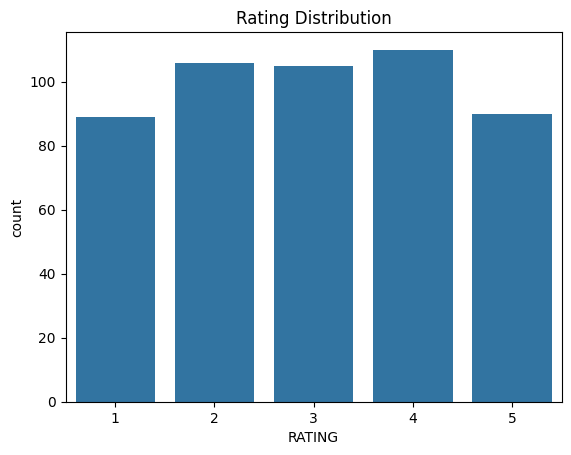

In [16]:
sns.countplot(x='RATING', data=df)
plt.title('Rating Distribution')
plt.show()

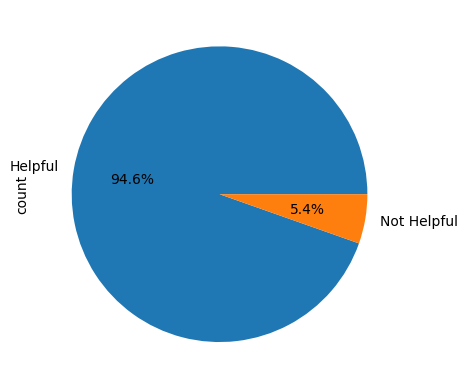

In [17]:
df['HELPFUL_CATEGORY'] = np.where(
    df['HELPFUL_VOTES'] > 10,
    'Helpful',
    'Not Helpful'
)

df['HELPFUL_CATEGORY'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.show()

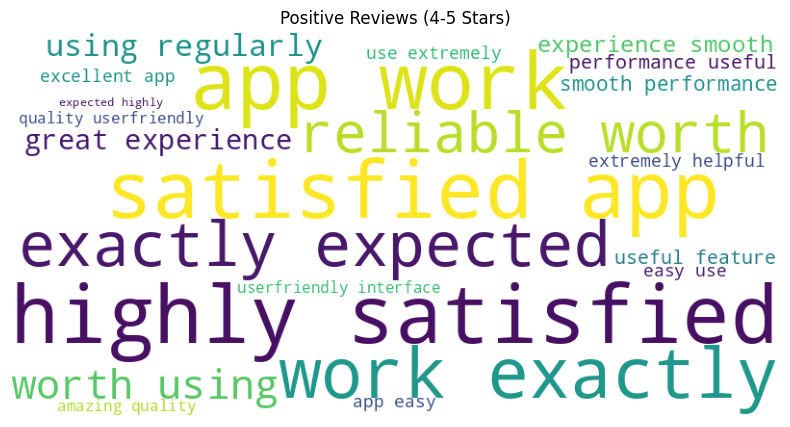

In [19]:
positive_text = " ".join(
    df[df["RATING"].isin([4,5])]["CLEAN_REVIEW"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews (4-5 Stars)")
plt.show()

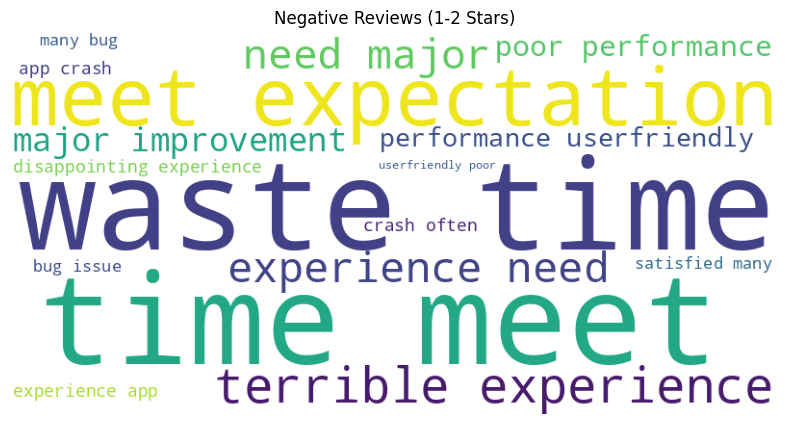

In [20]:
negative_text = " ".join(
    df[df["RATING"].isin([1,2])]["CLEAN_REVIEW"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews (1-2 Stars)")
plt.show()

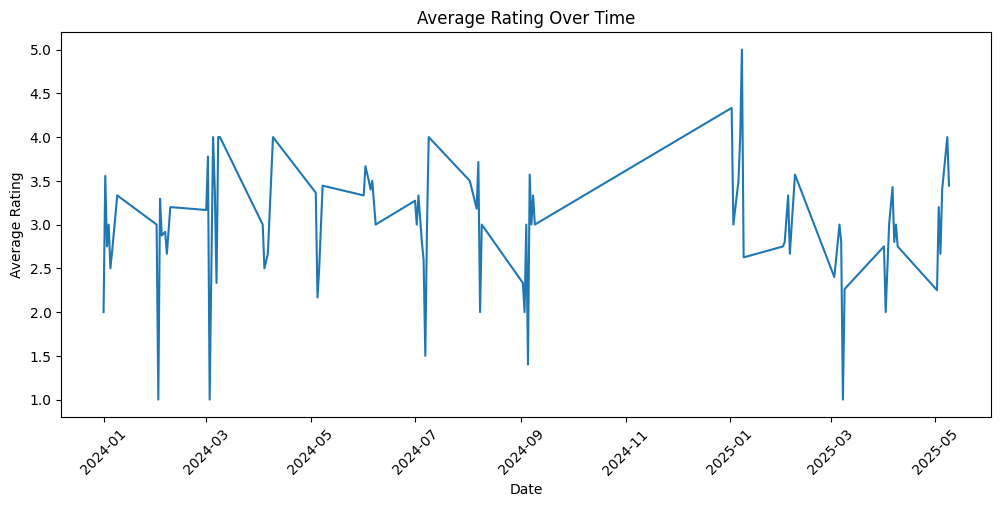

In [21]:
rating_trend = df.groupby("DATE")["RATING"].mean()

plt.figure(figsize=(12,5))

plt.plot(rating_trend.index, rating_trend.values)

plt.title("Average Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

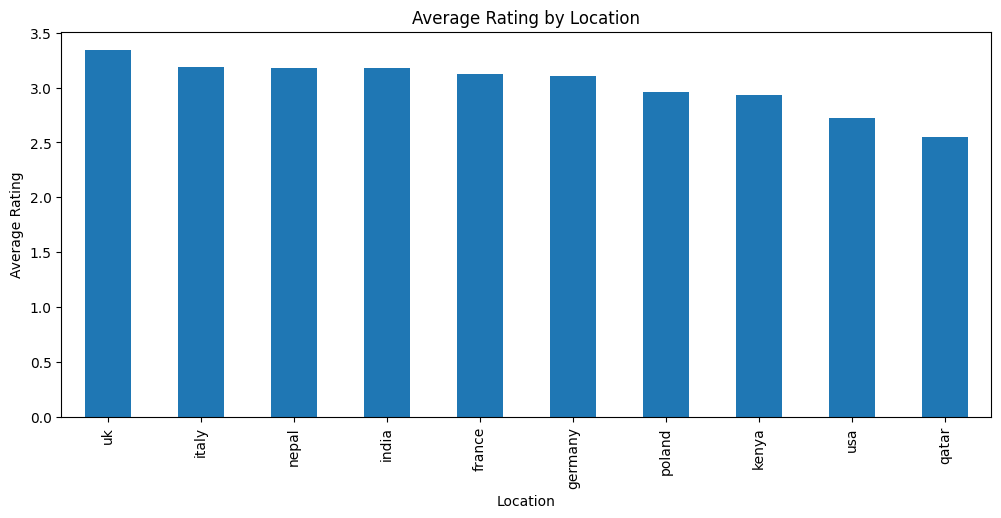

In [22]:
location_rating = (
    df.groupby("LOCATION")["RATING"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

location_rating.plot(kind="bar")

plt.title("Average Rating by Location")
plt.xlabel("Location")
plt.ylabel("Average Rating")

plt.show()

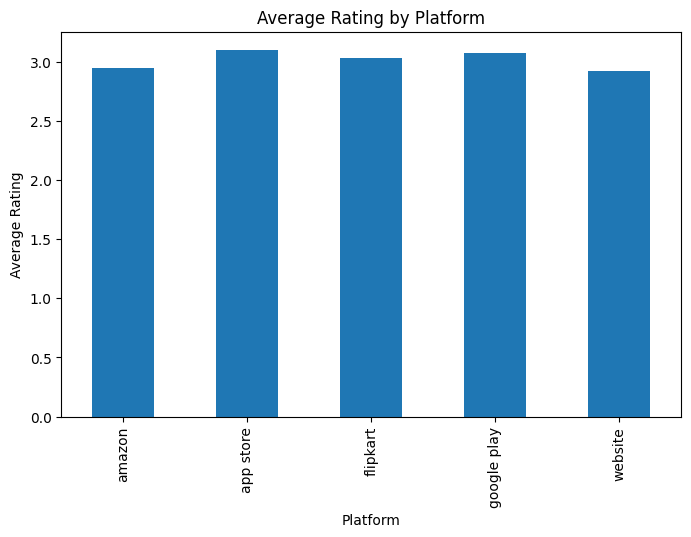

In [23]:
platform_rating = (
    df.groupby("PLATFORM")["RATING"]
    .mean()
)

plt.figure(figsize=(8,5))

platform_rating.plot(kind="bar")

plt.title("Average Rating by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Rating")

plt.show()

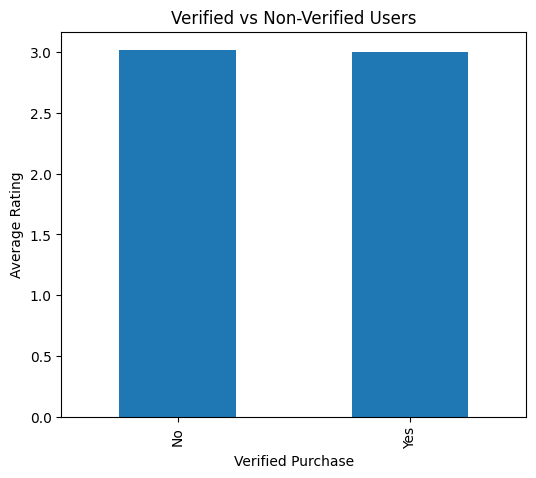

In [24]:
verified_rating = (
    df.groupby("VERIFIED_PURCHASE")["RATING"]
    .mean()
)

plt.figure(figsize=(6,5))

verified_rating.plot(kind="bar")

plt.title("Verified vs Non-Verified Users")
plt.xlabel("Verified Purchase")
plt.ylabel("Average Rating")

plt.show()

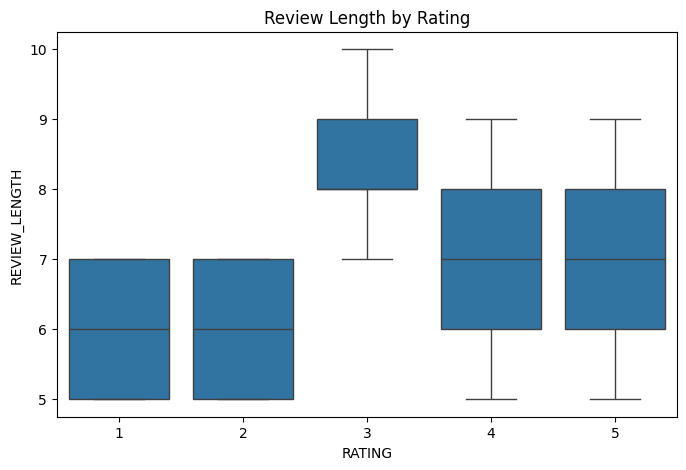

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="RATING",
    y="REVIEW_LENGTH",
    data=df
)

plt.title("Review Length by Rating")

plt.show()

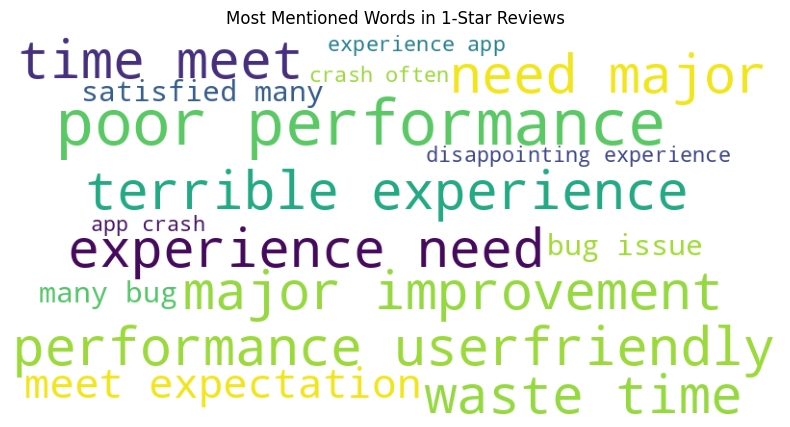

In [26]:
from wordcloud import WordCloud

one_star_text = " ".join(
    df[df["RATING"] == 1]["CLEAN_REVIEW"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(one_star_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Mentioned Words in 1-Star Reviews")

plt.show()

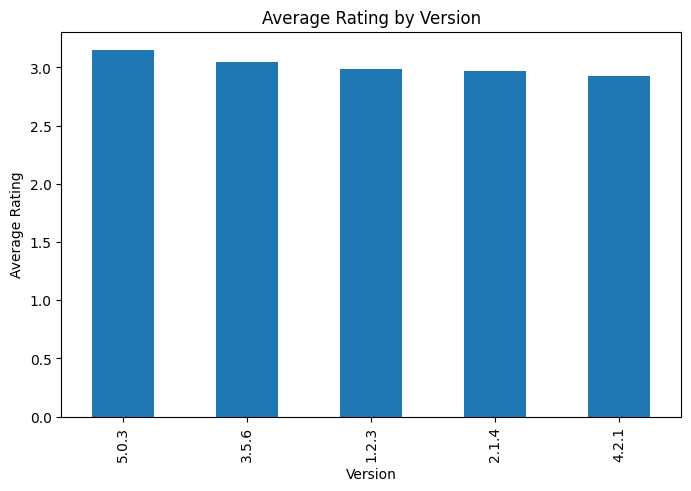

In [27]:
version_rating = (
    df.groupby("VERSION")["RATING"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

version_rating.plot(kind="bar")

plt.title("Average Rating by Version")
plt.xlabel("Version")
plt.ylabel("Average Rating")

plt.show()

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["CLEAN_REVIEW"])

y = df["SENTIMENT"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, nb_pred)

1.0

In [21]:
accuracy_score(y_test, lr_pred)

1.0

In [22]:
accuracy_score(y_test, rf_pred)

1.0

In [23]:
from sklearn.metrics import precision_score

precision_score(
    y_test,
    lr_pred,
    average='weighted'
)

1.0

In [24]:
from sklearn.metrics import recall_score

recall_score(
    y_test,
    lr_pred,
    average='weighted'
)

1.0

In [25]:
from sklearn.metrics import f1_score

f1_score(
    y_test,
    lr_pred,
    average='weighted'
)

1.0

In [26]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        36
     Neutral       1.00      1.00      1.00        25
    Positive       1.00      1.00      1.00        39

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



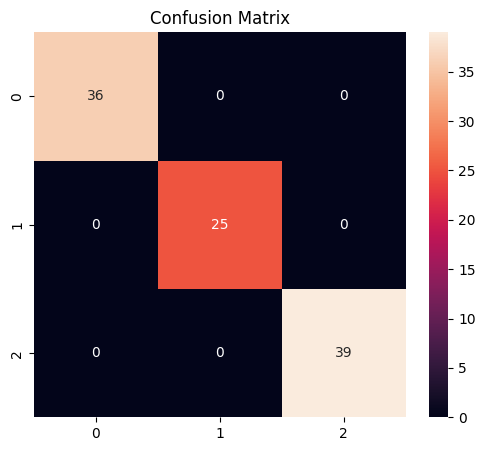

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [28]:
results = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[

        accuracy_score(
            y_test,
            nb_pred
        ),

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        )
    ]
})

results

,Model,Accuracy
0,Naive Bayes,1.0
1,Logistic Regression,1.0
2,Random Forest,1.0


In [29]:
results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Naive Bayes,1.0
1,Logistic Regression,1.0
2,Random Forest,1.0


In [30]:
import joblib

joblib.dump(
    lr_model,
    "sentiment_model.pkl"
)

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

['tfidf_vectorizer.pkl']

In [45]:
from google.colab import files
uploaded = files.upload()

Saving tfidf_vectorizer.pkl to tfidf_vectorizer (1).pkl
Saving sentiment_model.pkl to sentiment_model (1).pkl


In [46]:
import joblib

model = joblib.load("sentiment_model.pkl")

tfidf = joblib.load("tfidf_vectorizer.pkl")

In [31]:
!pip install streamlit pyngrok

In [32]:
!ngrok config add-authtoken 3BRppeBEOBO7wRyMKdKr4FGVLbT_esdNgukSRgKgMSZtVJxr

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [37]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# ---------------------------
# LOAD DATASET
# ---------------------------

df = pd.read_csv("/content/chatgpt_style_reviews_dataset.csv")

# ---------------------------
# LOAD MODEL
# ---------------------------

model = joblib.load("sentiment_model.pkl")

tfidf = joblib.load("tfidf_vectorizer.pkl")

# ---------------------------
# TITLE
# ---------------------------

st.title("AI Echo: Your Smartest Conversational Partner")

st.write("Sentiment Analysis of ChatGPT User Reviews")

# ---------------------------
# DATASET PREVIEW
# ---------------------------

st.header("Dataset Preview")

st.dataframe(df)

# ---------------------------
# SENTIMENT DISTRIBUTION
# ---------------------------

st.header("Sentiment Distribution")

sentiment_counts = df["SENTIMENT"].value_counts()

fig, ax = plt.subplots()

ax.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

ax.set_title("Sentiment Distribution")

ax.set_xlabel("Sentiment")

ax.set_ylabel("Count")

st.pyplot(fig)

# ---------------------------
# RATING DISTRIBUTION
# ---------------------------

st.header("Rating Distribution")

rating_counts = df["RATING"].value_counts().sort_index()

fig, ax = plt.subplots()

ax.bar(
    rating_counts.index,
    rating_counts.values
)

ax.set_title("Rating Distribution")

ax.set_xlabel("Rating")

ax.set_ylabel("Count")

st.pyplot(fig)

# ---------------------------
# PLATFORM ANALYSIS
# ---------------------------

st.header("Platform Analysis")

platform_rating = (
    df.groupby("PLATFORM")["RATING"]
    .mean()
)

fig, ax = plt.subplots()

platform_rating.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Average Rating by Platform")

st.pyplot(fig)

# ---------------------------
# VERSION ANALYSIS
# ---------------------------

st.header("Version Analysis")

version_rating = (
    df.groupby("VERSION")["RATING"]
    .mean()
)

fig, ax = plt.subplots()

version_rating.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Average Rating by Version")

st.pyplot(fig)

# ---------------------------
# SENTIMENT PREDICTION
# ---------------------------

st.header("Predict Sentiment")

user_review = st.text_area(
    "Enter Review"
)

if st.button("Predict Sentiment"):

    review_vector = tfidf.transform(
        [user_review]
    )

    prediction = model.predict(
        review_vector
    )

    st.success(
        f"Predicted Sentiment: {prediction[0]}"
    )

# ---------------------------
# MODEL PERFORMANCE
# ---------------------------

st.header("Model Performance")

st.write("Model Used: Logistic Regression")

st.write("Evaluation Metrics Generated During Training")

# ---------------------------
# PROJECT INSIGHTS
# ---------------------------

st.header("Insights")

st.write(
    """
    • Analyze customer satisfaction

    • Identify positive and negative reviews

    • Compare ratings across platforms

    • Compare ratings across versions

    • Predict sentiment from user reviews
    """
)

Overwriting app.py


In [38]:
from pyngrok import ngrok
!streamlit run app.py &>/dev/null &
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://cosily-musclebound-lovetta.ngrok-free.dev" -> "http://localhost:8501">

In [39]:
!streamlit run app.py &>/content/logs.txt &